# ArabicBERT

In [1]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import torch
print("="*50)
print("GPU CHECK")
print("="*50)
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("WARNING: No GPU detected!")
    print("Go to Settings → Accelerator → Select 'GPU T4 x2'")
print("="*50)

GPU CHECK
CUDA available: True
Device count: 1
Current device: 0
Device name: Tesla P100-PCIE-16GB
CUDA version: 12.6


In [4]:
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

from datasets import Dataset, load_dataset, DatasetDict
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    cohen_kappa_score, 
    classification_report,
    confusion_matrix, 
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

E0000 00:00:1770743951.416299      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770743951.480634      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770743951.997913      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770743951.997970      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770743951.997973      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770743951.997975      55 computation_placer.cc:177] computation placer already registered. Please check linka

In [5]:
MODEL_NAME = "asafaya/bert-base-arabic"
path = "/kaggle/input/bayyin-refined/Refined_Bayyin_Dataset.csv"

In [6]:
OUTPUT_DIR_D3TOK = "/kaggle/working/runs/ArabicBERT_D3Tok"

SAVE_DIR_D3TOK = "/kaggle/working/ArabicBERT_D3Tok"

In [7]:
#Training parameters
LABEL_COL = "Readability_Level"
LEVELS = [1, 2, 3, 4, 5, 6]
LR = 5e-5
BATCH = 64
EPOCHS = 6
MAX_LEN = 128
SEED = 42
SOFT_BETA = 2.0

## Data Preparation

In [8]:
print("\nLoading dataset...")
dataset = load_dataset("csv", data_files={"train": path}, split="train")
print(f"Dataset columns: {dataset.column_names}")
print(f"Dataset size: {len(dataset)}")


Loading dataset...


Generating train split: 0 examples [00:00, ? examples/s]

Dataset columns: ['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex', 'Readability_Level', 'Document', 'Source', 'Book', 'Author', 'Domain', 'Text_Class', 'Dataset_Source']
Dataset size: 44917


In [9]:
required_columns = ["D3Tok", LABEL_COL]
missing = [col for col in required_columns if col not in dataset.column_names]
if missing:
    print(f"Missing columns: {missing}")

In [10]:
level2id = {lvl: i for i, lvl in enumerate(LEVELS)}
id2level = {i: lvl for lvl, i in level2id.items()}

def map_labels(ds):
    return ds.map(lambda ex: {"labels": level2id[int(ex[LABEL_COL])]})

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [11]:
train_test = dataset.train_test_split(test_size=0.3, seed=SEED)
test_valid = train_test["test"].train_test_split(test_size=1/3, seed=SEED)
splits = DatasetDict({
    "train": train_test["train"],
    "test": test_valid["train"],
    "validation": test_valid["test"],
})
print(f"Train: {len(splits['train'])}, Test: {len(splits['test'])}, Val: {len(splits['validation'])}")

Train: 31441, Test: 8984, Val: 4492


## Model Training

In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    qwk = cohen_kappa_score(labels, preds, weights="quadratic")
    return {"accuracy": acc, "macro_f1": macro_f1, "qwk": qwk}

In [13]:
class OrdinalAwareTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        probs = torch.softmax(logits, dim=-1)

        # HARD EXAMPLE WEIGHTING
        true_probs = probs.gather(1, labels.unsqueeze(1)).squeeze()

        # Hard sample → low confidence → high weight
        difficulty_weight = 1.0 - true_probs.detach()

        # Stabilize
        difficulty_weight = difficulty_weight + 0.5
        difficulty_weight = difficulty_weight / difficulty_weight.mean()

        # ORDINAL DISTANCE PENALTY
        K = logits.shape[-1]
        indices = torch.arange(K).float().to(logits.device)

        labels_float = labels.float().unsqueeze(1)
        dist = torch.abs(indices - labels_float)

        distance_penalty = torch.exp(-dist / 2.0)
        distance_penalty = distance_penalty / distance_penalty.sum(dim=1, keepdim=True)

        # BASE LOSS (Cross Entropy)
        ce_loss = F.cross_entropy(logits, labels, reduction="none")

        # APPLY WEIGHTS
        weighted_loss = ce_loss * difficulty_weight

        # Optional small ordinal regularization
        log_probs = F.log_softmax(logits, dim=-1)
        ordinal_loss = F.kl_div(log_probs, distance_penalty, reduction="none").sum(dim=1)

        final_loss = (weighted_loss + 0.4 * ordinal_loss).mean()

        return (final_loss, outputs) if return_outputs else final_loss

In [14]:
def eval_and_report(ds, name, trainer_obj):
    out = trainer_obj.predict(ds)
    preds = out.predictions.argmax(-1)
    print(f"\n{'='*60}")
    print(f"{name} Metrics")
    print('='*60)
    print(out.metrics)
    y_true = ds["labels"]
    target_names = [f"L{lvl}" for lvl in LEVELS]
    print("\nPer-class F1:")
    print(classification_report(y_true, preds, target_names=target_names, digits=4))

In [15]:
def plot_confusion_matrix_normalized(ds, trainer_obj, title_suffix="", normalize='true', cmap='Blues'):
    preds_output = trainer_obj.predict(ds)
    y_true = ds["labels"]
    y_pred = preds_output.predictions.argmax(-1)
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"{lvl}" for lvl in LEVELS])
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap=cmap, values_format=".2f", ax=ax, colorbar=True)
    plt.title(f"Normalized Confusion Matrix - {title_suffix}")
    plt.tight_layout()
    plt.show()

In [16]:
def train_model(text_col, output_dir, save_dir, model_name="Model"):
    print(f"\n{'#'*60}")
    print(f"# TRAINING MODEL: {model_name}")
    print(f"# Text Column: {text_col}")
    print(f"{'#'*60}\n")

    def tokenize_fn(batch):
        return tokenizer(batch[text_col], truncation=True, padding="max_length", max_length=MAX_LEN)
    
    train_ds = map_labels(splits["train"]).map(tokenize_fn, batched=True)
    val_ds = map_labels(splits["validation"]).map(tokenize_fn, batched=True)
    test_ds = map_labels(splits["test"]).map(tokenize_fn, batched=True)

    cols = ["input_ids", "attention_mask", "labels"]
    train_ds.set_format(type="torch", columns=cols)
    val_ds.set_format(type="torch", columns=cols)
    test_ds.set_format(type="torch", columns=cols)

    print(f"Loading model: {MODEL_NAME}")
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(LEVELS))

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=LR,
        per_device_train_batch_size=BATCH,
        per_device_eval_batch_size=BATCH,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        warmup_ratio=0.1,
        load_best_model_at_end=True,
        metric_for_best_model="qwk",
        greater_is_better=True,
        seed=SEED,
        report_to="none",
        save_total_limit=3,
        save_safetensors=False,
        fp16=torch.cuda.is_available(),
    )

    trainer = OrdinalAwareTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
    )

    print(f"Starting Training for ArabicBERT for {EPOCHS} epochs...")
    trainer.train()

    print(f"\nSaving fine-tuned model to: {save_dir}")
    trainer.model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print("Model and tokenizer saved successfully!")

    print("\nEvaluating on Test Set...")
    eval_and_report(test_ds, f"Test (ArabicBERT - D3Tok)", trainer)
    plot_confusion_matrix_normalized(test_ds, trainer, title_suffix=model_name)

    return trainer, test_ds

In [17]:
def print_summary(results):
    """Print a comparison summary of all models"""
    print("\n" + "="*80)
    print("FINAL RESULTS SUMMARY")

    # Find best model for each metric
    best_acc = max(results.items(), key=lambda x: x[1].get('eval_accuracy', 0))
    best_f1 = max(results.items(), key=lambda x: x[1].get('eval_macro_f1', 0))
    best_qwk = max(results.items(), key=lambda x: x[1].get('eval_qwk', 0))
    
    print(f"\nAccuracy: {best_acc[0]} ({best_acc[1].get('eval_accuracy', 0):.4f})")
    print(f"Macro F1: {best_f1[0]} ({best_f1[1].get('eval_macro_f1', 0):.4f})")
    print(f"QWK: {best_qwk[0]} ({best_qwk[1].get('eval_qwk', 0):.4f})")
    print("="*80)

STARTING TRAINING PIPELINE - ArabicBERT

############################################################
# TRAINING MODEL: ArabicBERT
# Text Column: D3Tok
############################################################



Map:   0%|          | 0/31441 [00:00<?, ? examples/s]

Map:   0%|          | 0/31441 [00:00<?, ? examples/s]

Map:   0%|          | 0/4492 [00:00<?, ? examples/s]

Map:   0%|          | 0/4492 [00:00<?, ? examples/s]

...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at asafaya/bert-base-arabic and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting Training for ArabicBERT for 6 epochs...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk
1,1.257100,1.145258,0.727293,0.716767,0.814530
2,0.964900,1.023128,0.777382,0.777813,0.858741
3,0.762800,1.113624,0.770481,0.769605,0.865086
4,0.603200,1.201298,0.771594,0.769415,0.860101
5,0.514600,1.258554,0.781167,0.779101,0.871781
6,0.462600,1.308524,0.780944,0.779280,0.869643



Saving fine-tuned model to: /kaggle/working/ArabicBERT_D3Tok
Model and tokenizer saved successfully!

Evaluating on Test Set...



Test (ArabicBERT - D3Tok) Metrics
{'test_loss': 1.2827950716018677, 'test_accuracy': 0.7808325912733749, 'test_macro_f1': 0.7776413648021974, 'test_qwk': 0.8716044761447648, 'test_runtime': 32.1549, 'test_samples_per_second': 279.398, 'test_steps_per_second': 4.385}

Per-class F1:
              precision    recall  f1-score   support

          L1     0.7548    0.7986    0.7761      1519
          L2     0.7331    0.7153    0.7241      1528
          L3     0.7391    0.7746    0.7564      1353
          L4     0.6538    0.6228    0.6379      1437
          L5     0.8659    0.9072    0.8861      1530
          L6     0.9211    0.8522    0.8853      1617

    accuracy                         0.7808      8984
   macro avg     0.7780    0.7784    0.7776      8984
weighted avg     0.7814    0.7808    0.7806      8984



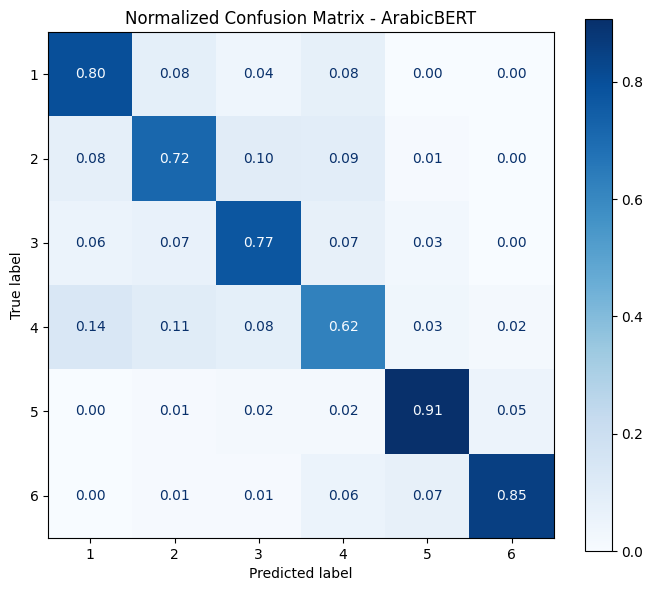


FINAL RESULTS SUMMARY

Accuracy: D3Tok (0.7808)
Macro F1: D3Tok (0.7776)
QWK: D3Tok (0.8716)

ALL TRAINING COMPLETE!

Model saved to:
  - /kaggle/working/ArabicBERT_D3Tok



In [18]:
if __name__ == "__main__":
    results = {}
    print("STARTING TRAINING PIPELINE - ArabicBERT")

    # Train D3Tok
    trainer_d3tok, test_ds_d3tok = train_model("D3Tok", OUTPUT_DIR_D3TOK, SAVE_DIR_D3TOK, "ArabicBERT")
    results["D3Tok"] = trainer_d3tok.evaluate(test_ds_d3tok)

    # Summary
    print_summary(results)
    print("\n" + "="*80)
    print("ALL TRAINING COMPLETE!")
    print("="*80)
    print(f"\nModel saved to:\n  - {SAVE_DIR_D3TOK}\n")
    print("="*80)